In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/noshowappointments - noshowappointments (2).csv")
df


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56.0,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51.0,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21.0,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38.0,MARIA ORTIZ,0,0,0,0,0,1,No


In [10]:


print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [6]:

# STEP 4: REMOVE DUPLICATES

initial_rows = len(df)

df = df.drop_duplicates()

final_rows = len(df)
print(f"\nDuplicates Removed: {initial_rows - final_rows}")


Duplicates Removed: 0


In [39]:

# STEP 5: HANDLE MISSING VALUES


df = df.fillna("1")


print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [40]:

# STEP 6: FIX DATA INCONSISTENCIES


# Convert all text columns to lowercase and remove extra spaces
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

# Example: Standardizing appointment status column
if 'appointment_status' in df.columns:
    df['appointment_status'] = df['appointment_status'].replace({
        'no show': 'no-show',
        'noshow': 'no-show',
        'cancelled': 'cancelled',
        'completed': 'completed'
    })


In [41]:

# STEP 7: CHECK DATA TYPES

print("\nFinal Data Types:")
print(df.dtypes)




Final Data Types:
PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                object
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [42]:

# STEP 8: SAVE CLEANED DATASET

df.to_csv('/content/cleaned_dataset.csv', index=False)

print("\nData cleaning completed and file saved as 'cleaned_dataset.csv'")


Data cleaning completed and file saved as 'cleaned_dataset.csv'


#Perform descriptive analysis: total records, appointment status split, and neighbourhood-wise counts.

In [43]:

# STEP 1: LOAD CLEANED DATASET

import pandas as pd

clean = pd.read_csv('/content/cleaned_dataset.csv')

# STEP 2: TOTAL RECORDS

print("Total Records:", len(df))


Total Records: 110527


In [44]:


# STEP 3: APPOINTMENT STATUS SPLIT

status_counts = clean['No-show'].value_counts()

print("\nAppointment Status Split:")
print(status_counts)



Appointment Status Split:
No-show
no     88208
yes    22319
Name: count, dtype: int64


In [45]:

# STEP 4: NEIGHBOURHOOD-WISE COUNTS

neighbourhood_counts = clean['Neighbourhood'].value_counts()

print("\nNeighbourhood-wise Counts:")
print(neighbourhood_counts)


Neighbourhood-wise Counts:
Neighbourhood
jardim camburi                 7717
maria ortiz                    5805
resistência                    4429
jardim da penha                3876
itararé                        3514
                               ... 
ilha do frade                    10
aeroporto                         8
unknown                           7
ilhas oceânicas de trindade       2
parque industrial                 1
Name: count, Length: 82, dtype: int64


In [19]:
clean.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

#Calculate the percentage distribution for appointment status.

In [46]:

# CALCULATE COUNTS

status_counts = clean['No-show'].value_counts()


# CALCULATE PERCENTAGE

status_percentage = (status_counts / len(clean)) * 100


# OPTIONAL: BETTER LABELS

status_percentage = status_percentage.rename({
    'No': 'Completed',
    'Yes': 'No-show'
})


# DISPLAY RESULT

print("Appointment Status Percentage Distribution:\n")
print(status_percentage.round(2))

Appointment Status Percentage Distribution:

No-show
no     79.81
yes    20.19
Name: count, dtype: float64


#Identify one trend or pattern (e.g., neighbourhood with higher cancellations or no-shows).

In [48]:

# NEIGHBOURHOOD vs NO-SHOW ANALYSIS


# Create a pivot table
trend = clean.groupby('Neighbourhood')['No-show'].value_counts().unstack()

# Replace NaN with 0
trend = trend.fillna(0)

#check actual column names
print("Columns:", trend.columns)

# ==========================================
# FIX: use correct column names dynamically
# ==========================================

yes_col = [col for col in trend.columns if str(col).lower() == 'yes'][0]
no_col = [col for col in trend.columns if str(col).lower() == 'no'][0]

# Calculate No-show percentage
trend['No-show %'] = (trend[yes_col] / (trend[yes_col] + trend[no_col])) * 100

# Sort by highest no-show %
trend_sorted = trend.sort_values(by='No-show %', ascending=False)

# Show top 10 areas with highest no-show
print(trend_sorted.head(10))

Columns: Index(['no', 'yes'], dtype='object', name='No-show')
No-show                          no    yes   No-show %
Neighbourhood                                         
ilhas oceânicas de trindade     0.0    2.0  100.000000
santos dumont                 907.0  369.0   28.918495
santa cecília                 325.0  123.0   27.455357
santa clara                   372.0  134.0   26.482213
itararé                      2591.0  923.0   26.266363
jesus de nazareth            2157.0  696.0   24.395373
horto                         133.0   42.0   24.000000
ilha do príncipe             1734.0  532.0   23.477493
caratoíra                    1974.0  591.0   23.040936
andorinhas                   1741.0  521.0   23.032714


#Create 2 visualisations (bar/column/pie charts).

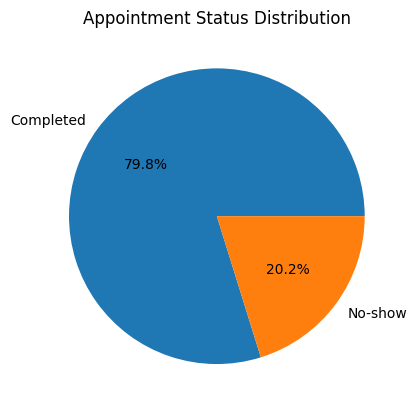

In [32]:
import matplotlib.pyplot as plt

# Count values
status_counts = clean['No-show'].value_counts()

# Rename for better labels
status_counts = status_counts.rename({
    'No': 'Completed',
    'Yes': 'No-show',
    'no': 'Completed',
    'yes': 'No-show'
})

# Plot Pie Chart
plt.figure()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Appointment Status Distribution')

plt.show()

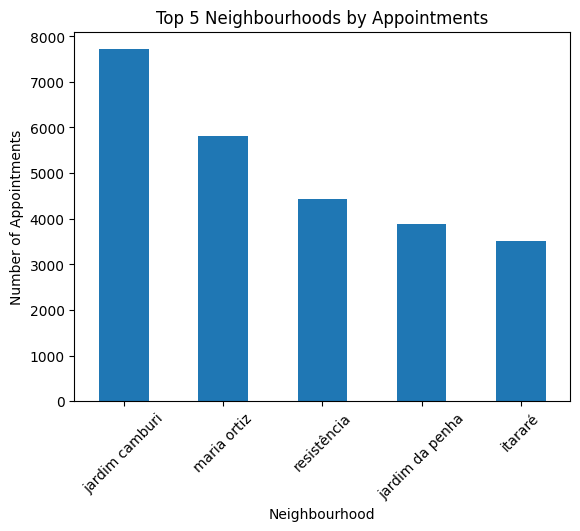

In [33]:
# Get top 5 neighbourhoods
top_neighbourhoods = clean['Neighbourhood'].value_counts().head(5)

# Plot Bar Chart
plt.figure()
top_neighbourhoods.plot(kind='bar')

plt.title('Top 5 Neighbourhoods by Appointments')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Appointments')

plt.xticks(rotation=45)

plt.show()

#●
Create 2 visualisations (bar/column/pie charts).


1.   The dataset contains 110,527 appointment records, and no missing values or duplicates were found after cleaning, indicating high data quality.
2.  Approximately 79.81% of appointments were completed, while 20.19% resulted in no-shows, showing that about 1 in 5 patients miss their appointments.


1.   Certain neighbourhoods such as Jardim Camburi, Maria Ortiz, and Resistência have the highest number of appointments, indicating higher patient demand in these areas.
2.   Some neighbourhoods exhibit significantly higher no-show rates. For example, Ilhas Oceânicas de Trindade shows a 100% no-show rate, while areas like Santos Dumont and Santa Cecília also have relatively high no-show percentages (above 25%).


1.   The variation in no-show rates across neighbourhoods suggests that location-based factors (such as accessibility or awareness) may influence patient attendance, and targeted interventions in high no-show areas could improve hospital efficiency.

